<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Hi" data-toc-modified-id="Hi-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Hi</a></span></li></ul></div>

Grid World
- 1)
- 2)
- 3)
    - 3a)
    - 3b)
    - 3c)
    - 3d)
- 4)
    - 4a)
    - 4b)
    - 4c)
    - 4d)

Acrobort
- 1)
- 2)
- 3)
    - 3a)
    - 3b)
    - 3c)
    - 3d)
- 4)
    - 4a)
    - 4b)
    - 4c)
    - 4d)
    

### MDP Design and demonstration around point (3,3)
- MDP is completely designed at [core/Agent/mdp_model.py](core/Agent/mdp_model.py)
- **Transition Probabilities**: For a fixed start state $s = (3,3)$, the probability of landing in neighbor $s'$ given action $a$: $P(s, a, s')$
- **Expected Reward**: The reward stored in  MDP model for an action: $R(s, a) = \sum_{s'} P(s, a, s') \cdot r(s, s')$
- **Outcome Reward**: The reward for actually landing in a specific neighbor $s'$ (what Question 1 asks for): $r(s, s')$
    - $$r(s, a, s') = R(s'), \quad \forall s \in S, \forall a \in A$$
    - we need $r(s,s') = \sum_{a}*\pi(a|s)*P(a,s,s')*r(a,s,s')$ which simplyfies to
    - As $\pi(a|s) = 0.25$ i.e... Random the both the above equations combine to give
    - $r(s,s') = R(s')$

c:\Users\gurra\anaconda3\envs\RL_ass1_1\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128167 (\N{DROPLET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


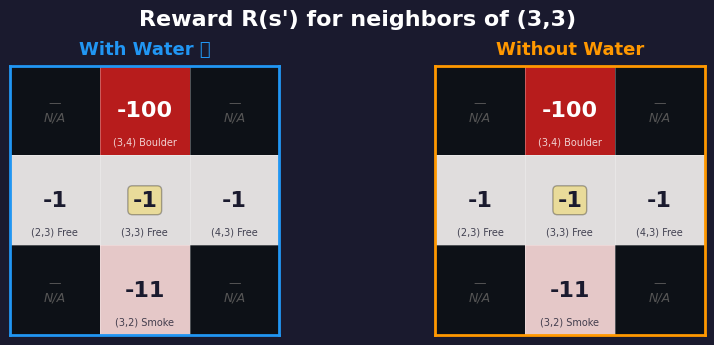

In [34]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

cx, cy = 3, 3

# 9 neighbor cells arranged: top row = y+1, mid = y, bot = y-1
neighbors = []
for dy in [1, 0, -1]:
    for dx in [-1, 0, 1]:
        neighbors.append((cx + dx, cy + dy))

# Diagonal offsets (unreachable in one step)
diag_offsets = {(-1, 1), (1, 1), (-1, -1), (1, -1)}

# Custom diverging colormap: red → white → green (matching dark theme)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'reward', ['#b71c1c', '#e53935', '#ef9a9a', '#e0e0e0', '#a5d6a7', '#43a047', '#1b5e20'])

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), facecolor='#1a1a2e')
fig.suptitle(f'Reward R(s\') for neighbors of ({cx},{cy})',
             fontsize=16, fontweight='bold', color='white')

phase_names = ['With Water 💧', 'Without Water']
phase_colors = ['#2196F3', '#FF9800']

for idx, (w, ax) in enumerate(zip([1, 0], axes)):
    grid = np.full((3, 3), np.nan)

    for i, (nx, ny) in enumerate(neighbors):
        dx, dy = nx - cx, ny - cy
        r_row, c_col = i // 3, i % 3

        # Diagonals are unreachable → leave as NaN
        if (dx, dy) in diag_offsets:
            continue

        s_prime = nx + 5 * ny + 25 * w
        label = S[s_prime]

        if "Boulder" in label:
            grid[r_row, c_col] = -100.0
        elif "Fire" in label and w == 1:
            grid[r_row, c_col] = 100.0
        else:
            val = -1.0
            if "Smoke" in label:
                val -= 10.0
            grid[r_row, c_col] = val

    # Mask NaN for colormap
    masked = np.ma.masked_invalid(grid)
    cmap_copy = cmap.copy()
    cmap_copy.set_bad(color='#0d1117')  # dark for unreachable

    ax.imshow(masked, cmap=cmap_copy, vmin=-100, vmax=100, aspect='equal')
    ax.set_title(phase_names[idx], fontsize=13, fontweight='bold',
                 color=phase_colors[idx], pad=8)

    for r_row in range(3):
        for c_col in range(3):
            nx, ny = neighbors[r_row * 3 + c_col]
            dx, dy = nx - cx, ny - cy

            if (dx, dy) in diag_offsets:
                ax.text(c_col, r_row, '—\nN/A', ha='center', va='center',
                        fontsize=9, color='#555', style='italic')
                continue

            val = grid[r_row, c_col]
            s_prime = nx + 5 * ny + 25 * w
            cell_type = S[s_prime].split('_')[0]

            # Highlight center
            is_center = (nx == cx and ny == cy)
            bbox = dict(boxstyle='round,pad=0.2', facecolor='gold', alpha=0.3) if is_center else None

            txt_color = 'white' if abs(val) > 50 else '#1a1a2e'
            ax.text(c_col, r_row, f'{val:.0f}', ha='center', va='center',
                    fontsize=16, color=txt_color, fontweight='bold', bbox=bbox)
            ax.text(c_col, r_row + 0.35, f'({nx},{ny}) {cell_type}', ha='center', va='center',
                    fontsize=7, color=txt_color, alpha=0.8)

    # Grid lines
    for edge in [0.5, 1.5]:
        ax.axhline(edge, color='white', linewidth=0.5, alpha=0.4)
        ax.axvline(edge, color='white', linewidth=0.5, alpha=0.4)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#16213e')
    for spine in ax.spines.values():
        spine.set_color(phase_colors[idx])
        spine.set_linewidth(2)

plt.subplots_adjust(hspace=0.3, wspace=0.3, left=0.03, right=0.97, top=0.82, bottom=0.05)
plt.show()

### Need to fill with all these iterations and all
- In value iteration we use bellman operator to find find optimal value of V_pi
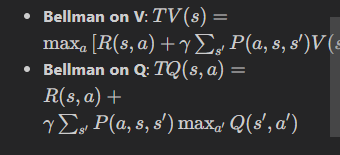

MDP verified: All components initialized and probabilities sum to 1.0
Value iteration converged in 176 iterations


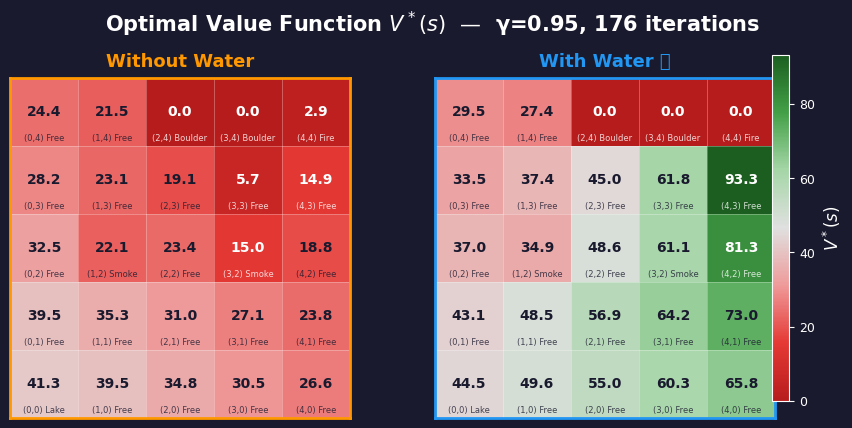

In [46]:
from core.Agent.agent import Agent
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

Ass1_agent = Agent(mdp)
V, n_iters = Ass1_agent.value_iteration_on_V(max_iter=1000)
print(f"Value iteration converged in {n_iters} iterations")

phase_names = ['Without Water', 'With Water 💧']
phase_colors = ['#FF9800', '#2196F3']

cmap = mcolors.LinearSegmentedColormap.from_list(
    'value', ['#b71c1c', '#e53935', '#ef9a9a', '#e0e0e0', '#a5d6a7', '#43a047', '#1b5e20'])

vmin, vmax = np.min(V), np.max(V)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), facecolor='#1a1a2e')
fig.suptitle(f'Optimal Value Function $V^*(s)$  —  γ={gamma}, {n_iters} iterations',
             fontsize=15, fontweight='bold', color='white')

for idx, (w, ax) in enumerate(zip([0, 1], axes)):
    grid = np.zeros((5, 5))
    for y in range(5):
        for x in range(5):
            s_idx = x + 5 * y + 25 * w
            grid[4 - y, x] = V[s_idx]

    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_title(phase_names[idx], fontsize=13, fontweight='bold',
                 color=phase_colors[idx], pad=8)

    for row in range(5):
        for col in range(5):
            y_coord = 4 - row  # actual grid y
            s_idx = col + 5 * y_coord + 25 * w
            val = V[s_idx]
            cell_type = S[s_idx].split('_')[0]

            txt_color = 'white' if abs(val - (vmin + vmax) / 2) > (vmax - vmin) * 0.3 else '#1a1a2e'

            # Value
            ax.text(col, row, f'{val:.1f}', ha='center', va='center',
                    fontsize=10, color=txt_color, fontweight='bold')
            # Cell type + coords
            ax.text(col, row + 0.38, f'({col},{y_coord}) {cell_type}', ha='center', va='center',
                    fontsize=6, color=txt_color, alpha=0.8)

    # Grid lines
    for edge in [0.5, 1.5, 2.5, 3.5]:
        ax.axhline(edge, color='white', linewidth=0.5, alpha=0.4)
        ax.axvline(edge, color='white', linewidth=0.5, alpha=0.4)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#16213e')
    for spine in ax.spines.values():
        spine.set_color(phase_colors[idx])
        spine.set_linewidth(2)

# Colorbar
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.03, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.outline.set_edgecolor('white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white', fontsize=9)
cbar.set_label('$V^*(s)$', color='white', fontsize=12)

plt.subplots_adjust(hspace=0.3, wspace=0.25, left=0.03, right=0.88, top=0.85, bottom=0.05)
plt.show()

#### optimal value Function and corssponding path
use the below for note taking later
"""
Path_generater():
- Takes input as the any one of the above 5*5 gird that is we give the value_fuction array of size 50 to it
And pass one argument saying water = true/false
- If water is false imples it just droped in the fire now so starting point = fire and then look all 4 directions and compare the value fuction and talking a greedy step
Do this till you reach the orgin If number of steps increasing more than 25 (Then just print warring that something went wrong terminating path after 25 steps)
- If water is true then start from water and end goal is reaching path

Finally just output path like this "path: Optional[List[Tuple[int, int]]] = None"

Need to have generate 2 Images
plot1:
- This when water is not there (i.e)... when we starting from fire after depositing water in the fire
start = (4,4) for the path_generater fuction pass water = false and take that path and give it to (generate_grid_image) for image
def generate_grid_image(    S: List[str],    path: Optional[List[Tuple[int, int]]] = None,    points_of_interest: Optional[List[Tuple[int, int]]] = None,    title: str = "Gridworld",    figsize: Tuple[float, float] = (4, 4),save_path: Optional[str] = None,    show: bool = True,    dark_bg: bool = True,water_phase: int = 0,):
- Use the above defintion and click on don't image but as it just return image store it

Then generate a plot where it has 3 subplots one is it value fuction image or fig generate in the above cell and the second is it path phsical in the world

plot2:
- Repeat the same when water is there that si starting from start = (4,4) and do the same thing
"""

MDP verified: All components initialized and probabilities sum to 1.0
Path (no water, Fire→Lake): [(4, 4), (4, 3), (4, 2), (4, 1), (3, 1), (2, 1), (1, 1), (1, 0), (0, 0)]  (8 steps)


MDP verified: All components initialized and probabilities sum to 1.0
Path (no water, Fire→Lake): [(4, 4), (4, 3), (4, 2), (4, 1), (3, 1), (2, 1), (1, 1), (1, 0), (0, 0)]  (8 steps)


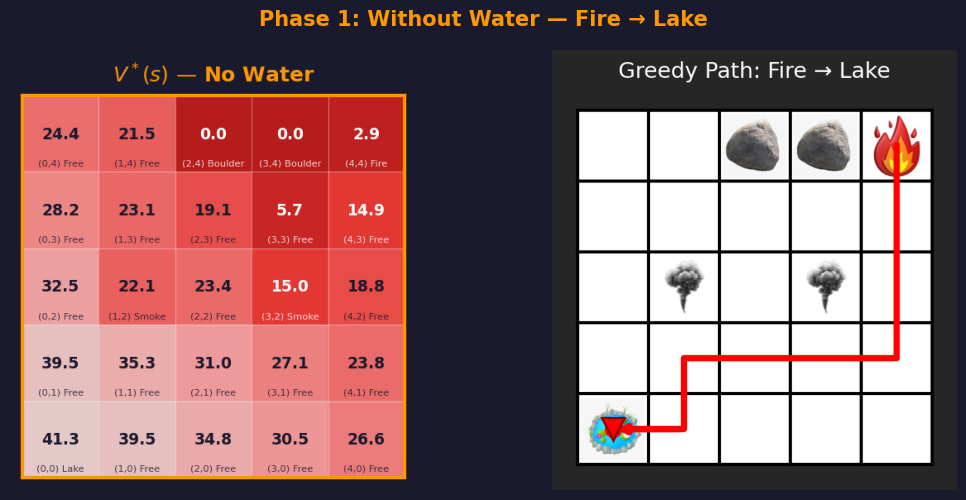

Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.


MDP verified: All components initialized and probabilities sum to 1.0
Path (no water, Fire→Lake): [(4, 4), (4, 3), (4, 2), (4, 1), (3, 1), (2, 1), (1, 1), (1, 0), (0, 0)]  (8 steps)


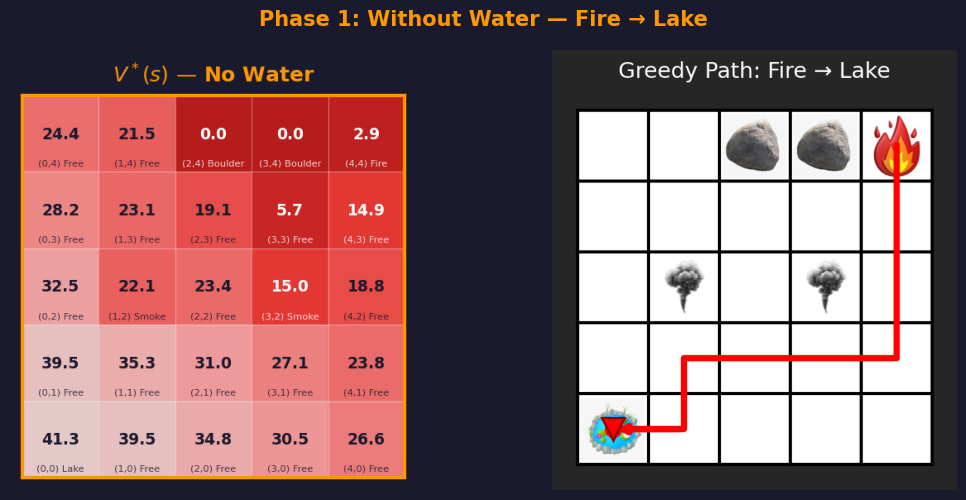

Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.



Path (with water, Lake→Fire): [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]  (8 steps)


MDP verified: All components initialized and probabilities sum to 1.0
Path (no water, Fire→Lake): [(4, 4), (4, 3), (4, 2), (4, 1), (3, 1), (2, 1), (1, 1), (1, 0), (0, 0)]  (8 steps)


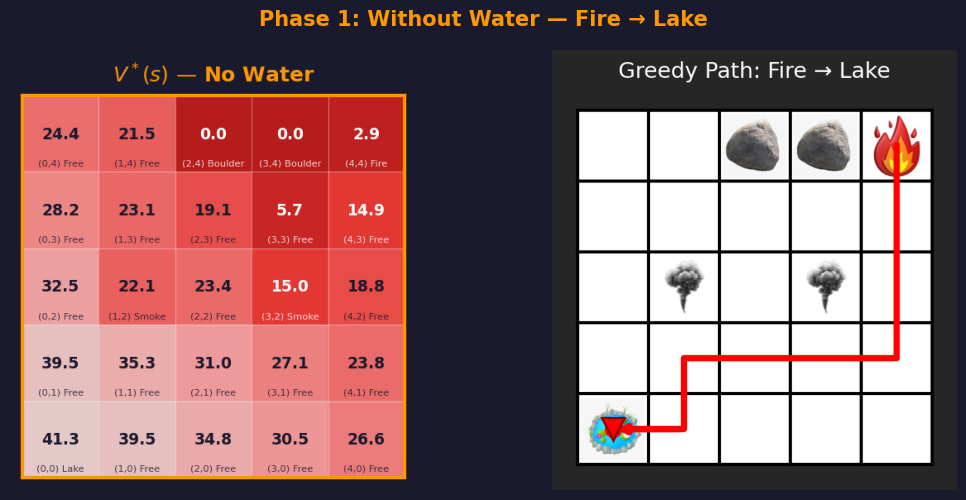

Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.



Path (with water, Lake→Fire): [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]  (8 steps)


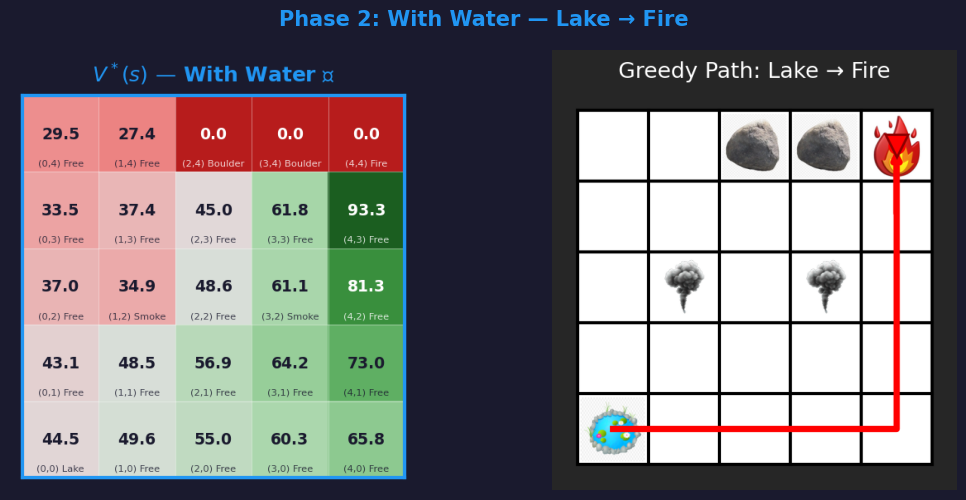

In [54]:
import importlib, core.Agent.agent as cAa
importlib.reload(cAa)
from core.Agent.agent import Agent
from core.Plot_generators.Grid_path_generator import generate_grid_image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from io import BytesIO
from PIL import Image as PILImage

# Re-create agent with converged V
Ass1_agent = Agent(mdp)
Ass1_agent.value_iteration_on_V(max_iter=1000)

# ── Helper: rasterize a matplotlib figure to an image array ──
def fig_to_array(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    buf.seek(0)
    img = np.array(PILImage.open(buf))
    buf.close()
    plt.close(fig)
    return img

# ── Helper: draw V heatmap as its own figure ──
def make_V_fig(V, S, w, title, title_color):
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'value', ['#b71c1c', '#e53935', '#ef9a9a', '#e0e0e0', '#a5d6a7', '#43a047', '#1b5e20'])
    vmin, vmax = np.min(V), np.max(V)

    fig, ax = plt.subplots(figsize=(4, 4), facecolor='#1a1a2e')
    grid = np.zeros((5, 5))
    for y in range(5):
        for x in range(5):
            grid[4 - y, x] = V[x + 5 * y + 25 * w]

    ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_title(title, fontsize=12, fontweight='bold', color=title_color, pad=8)

    for row in range(5):
        for col in range(5):
            yc = 4 - row
            s_idx = col + 5 * yc + 25 * w
            val = V[s_idx]
            cell_type = S[s_idx].split('_')[0]
            txt_color = 'white' if abs(val - (vmin + vmax) / 2) > (vmax - vmin) * 0.3 else '#1a1a2e'
            ax.text(col, row, f'{val:.1f}', ha='center', va='center',
                    fontsize=9, color=txt_color, fontweight='bold')
            ax.text(col, row + 0.38, f'({col},{yc}) {cell_type}', ha='center', va='center',
                    fontsize=5.5, color=txt_color, alpha=0.8)

    for edge in [0.5, 1.5, 2.5, 3.5]:
        ax.axhline(edge, color='white', linewidth=0.5, alpha=0.4)
        ax.axvline(edge, color='white', linewidth=0.5, alpha=0.4)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor('#16213e')
    for spine in ax.spines.values():
        spine.set_color(title_color); spine.set_linewidth(2)
    return fig

V = Ass1_agent.V

# ======================================================================
# PLOT 1: Without Water  — Fire(4,4) → Lake(0,0)
# ======================================================================
path_no_water = Ass1_agent.greedy_path(water=False)
print(f"Path (no water, Fire→Lake): {path_no_water}  ({len(path_no_water)-1} steps)")

# Generate both sub-images
fig_v1 = make_V_fig(V, S, w=0, title='$V^*(s)$ — No Water', title_color='#FF9800')
img_v1 = fig_to_array(fig_v1)

fig_p1, _ = generate_grid_image(S, path=path_no_water, points_of_interest=[(0, 0)],
                                 title='Greedy Path: Fire → Lake',
                                 figsize=(4, 4), show=False, water_phase=0)
img_p1 = fig_to_array(fig_p1)

# Compose side by side
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(11, 5), facecolor='#1a1a2e')
fig1.suptitle('Phase 1: Without Water — Fire → Lake',
              fontsize=15, fontweight='bold', color='#FF9800')

ax1a.imshow(img_v1); ax1a.axis('off')
ax1b.imshow(img_p1); ax1b.axis('off')

plt.subplots_adjust(wspace=0.05, left=0.02, right=0.98, top=0.90, bottom=0.02)
plt.show()

# ======================================================================
# PLOT 2: With Water  — Lake(0,0) → Fire(4,4)
# ======================================================================
path_water = Ass1_agent.greedy_path(water=True)
print(f"\nPath (with water, Lake→Fire): {path_water}  ({len(path_water)-1} steps)")

fig_v2 = make_V_fig(V, S, w=1, title='$V^*(s)$ — With Water 💧', title_color='#2196F3')
img_v2 = fig_to_array(fig_v2)

fig_p2, _ = generate_grid_image(S, path=path_water, points_of_interest=[(4, 4)],
                                 title='Greedy Path: Lake → Fire',
                                 figsize=(4, 4), show=False, water_phase=1)
img_p2 = fig_to_array(fig_p2)

fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(11, 5), facecolor='#1a1a2e')
fig2.suptitle('Phase 2: With Water — Lake → Fire',
              fontsize=15, fontweight='bold', color='#2196F3')

ax2a.imshow(img_v2); ax2a.axis('off')
ax2b.imshow(img_p2); ax2b.axis('off')

plt.subplots_adjust(wspace=0.05, left=0.02, right=0.98, top=0.90, bottom=0.02)
plt.show()

In [ ]:
""" 
- To Decrease in Ipynb I want to have something stream lined now we mainly have 2 types of images
1) Generate by the grid_generator
2) The colour gradient For value fuction and talking all other desction for plotiing the probalites Trasition etc...

Now I want to create 2 new files named
1) Value Fuction vizuvalizer (This file will have a fuction that takes in water = true or false) and depending on that will give a image in fig format as return (not show as we will make it false)
2) Anthor file name is point_sourringding_visvualizer whih has Transtion_probability_Reward_visuvalizer_around_a_point as a fuction that takes input as point and out 2 images the same that have been output images like the one in cell-7,9 even we need not to club them with anything we will still call them with img_show = false only to maintain unfiromity and in main code we will use that for image display and all
and any way generate_grid_image is already there
"""

## Step1:- Setup

Setup
This is the deflaut setup given in the assiginment


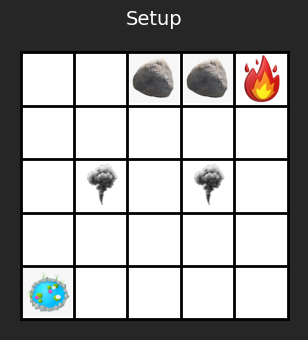

(<Figure size 350x350 with 1 Axes>, <Axes: title={'center': 'Setup'}>)

In [ ]:
print("===================================================")
print("Setup\nThis is the deflaut setup given in the assiginment")
print("===================================================")

from core.Agent.agent import Agent
from core.Agent.mdp_model import FiniteMDP
from core.Plot_generators.Grid_path_generator import generate_grid_image
from core.Plot_generators.point_sourringding_visvualizer import transition_probability_visualizer,reward_visualizer
from core.Plot_generators.value_fuction_visuvalizer import state_value_fuction_visuvalizer

mdp_model = FiniteMDP()
S, A, P, R, gamma = mdp_model.initialization_MDP_with_DA6400_Question1_manner(0.95)
generate_grid_image(S,figsize = (3.5,3.5) ,title = "Setup")

## Step2:- (Q1) Transition and reward matrices for starting from (3,3) --> (3 Marks)

Q1:- Transition and reward matrices for starting from (3,3) --> (3 Marks)


Q1:- Transition and reward matrices for starting from (3,3) --> (3 Marks)


C:\Users\gurra\AppData\Local\Temp\ipykernel_46916\3895259344.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_prob.show()
C:\Users\gurra\AppData\Local\Temp\ipykernel_46916\3895259344.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_reward.show()


NameError: name 'plt' is not defined

Q1:- Transition and reward matrices for starting from (3,3) --> (3 Marks)


C:\Users\gurra\AppData\Local\Temp\ipykernel_46916\3895259344.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_prob.show()
C:\Users\gurra\AppData\Local\Temp\ipykernel_46916\3895259344.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_reward.show()


NameError: name 'plt' is not defined

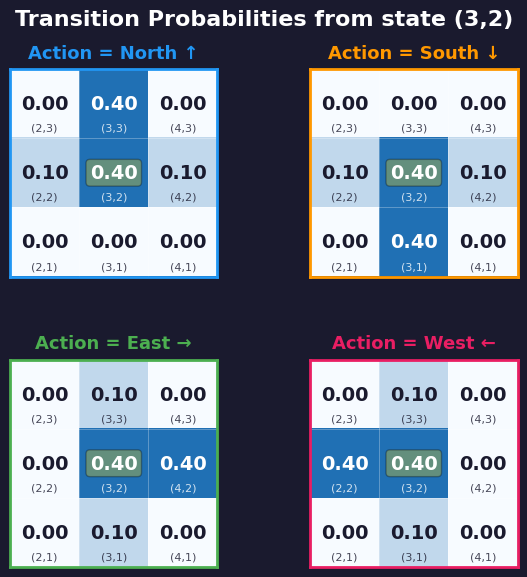

Q1:- Transition and reward matrices for starting from (3,3) --> (3 Marks)


C:\Users\gurra\AppData\Local\Temp\ipykernel_46916\3895259344.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_prob.show()
C:\Users\gurra\AppData\Local\Temp\ipykernel_46916\3895259344.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_reward.show()


NameError: name 'plt' is not defined

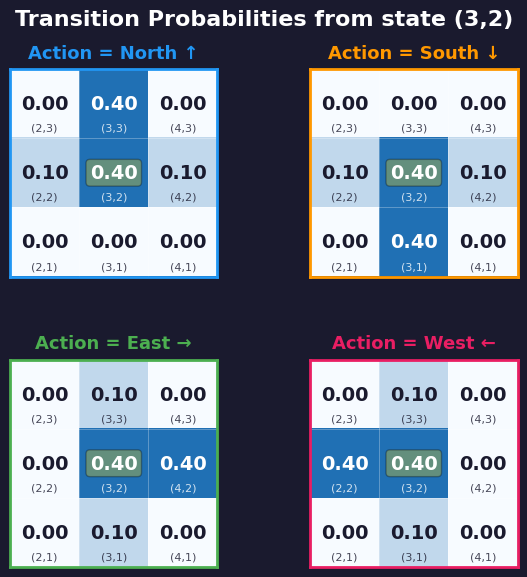

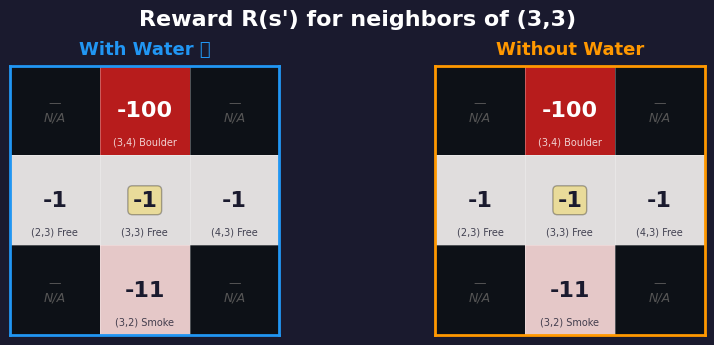

In [28]:
print("===================================================")
print("Q1:- Transition and reward matrices for starting from (3,3) --> (3 Marks)")
print("===================================================")

from core.Plot_generators.point_sourringding_visvualizer import transition_probability_visualizer,reward_visualizer
fig_prob,any = transition_probability_visualizer(point = (3,2),P=P,S=S,water = True,figsize = (6,6))
fig_reward,any = reward_visualizer(point = (3,3),S=S)
fig_prob.show()
fig_reward.show()

plt.show() #If any image is stuck it will show just safty

## Step-3 (Q2) optimal_value_function and optimal_policy generation and visuvalization (5 Marks)

Q2:- Optimal Value Function & Greedy Policy Path
MDP verified: All components initialized and probabilities sum to 1.0
Value iteration converged in 176 iterations  (γ=0.95)
Path (no water): [(4, 4), (4, 3), (4, 2), (4, 1), (3, 1), (2, 1), (1, 1), (1, 0), (0, 0)]  (8 steps)


Q2:- Optimal Value Function & Greedy Policy Path
MDP verified: All components initialized and probabilities sum to 1.0
Value iteration converged in 176 iterations  (γ=0.95)
Path (no water): [(4, 4), (4, 3), (4, 2), (4, 1), (3, 1), (2, 1), (1, 1), (1, 0), (0, 0)]  (8 steps)


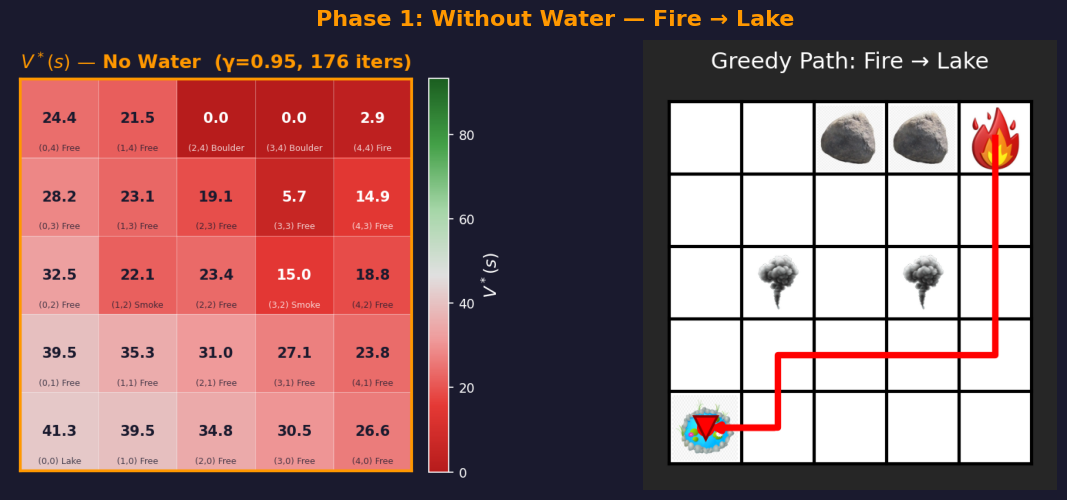

Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.


Q2:- Optimal Value Function & Greedy Policy Path
MDP verified: All components initialized and probabilities sum to 1.0
Value iteration converged in 176 iterations  (γ=0.95)
Path (no water): [(4, 4), (4, 3), (4, 2), (4, 1), (3, 1), (2, 1), (1, 1), (1, 0), (0, 0)]  (8 steps)


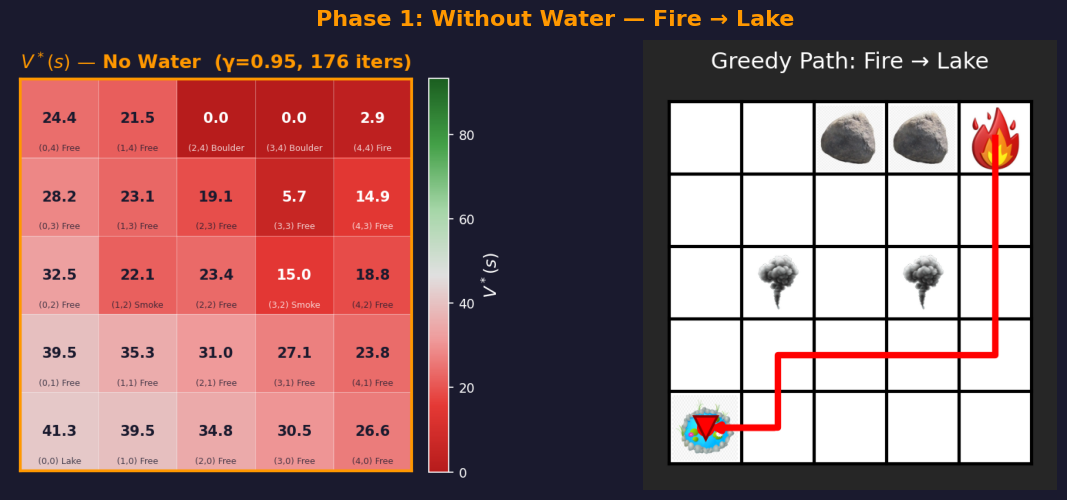

Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.


Path (with water): [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]  (8 steps)


Q2:- Optimal Value Function & Greedy Policy Path
MDP verified: All components initialized and probabilities sum to 1.0
Value iteration converged in 176 iterations  (γ=0.95)
Path (no water): [(4, 4), (4, 3), (4, 2), (4, 1), (3, 1), (2, 1), (1, 1), (1, 0), (0, 0)]  (8 steps)


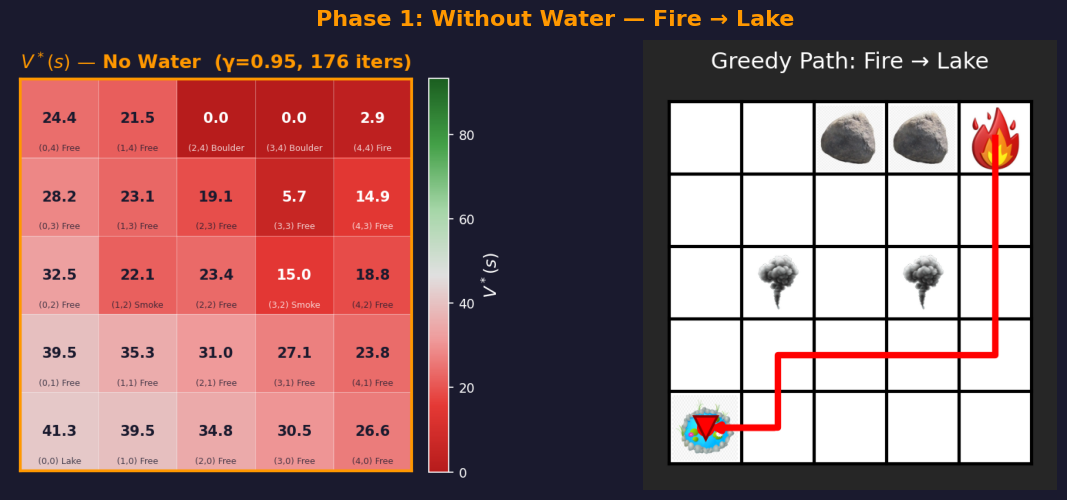

Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.


Path (with water): [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]  (8 steps)


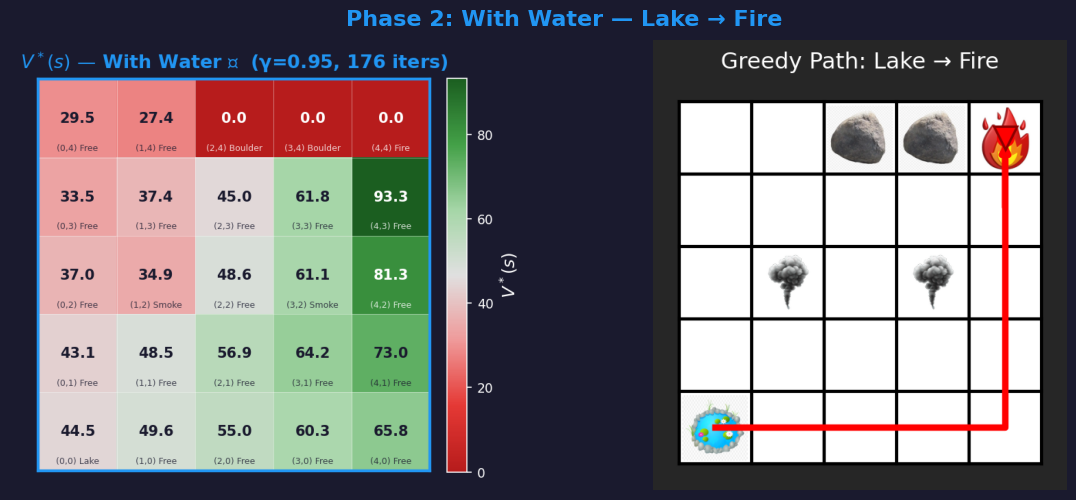

In [65]:
print("===================================================")
print("Q2:- Optimal Value Function & Greedy Policy Path")
print("===================================================")
from core.Agent.agent import Agent
from core.Plot_generators.Grid_path_generator import generate_grid_image
from core.Plot_generators.value_fuction_visuvalizer import state_value_fuction_visuvalizer
from core.Plot_generators.figuer_merger import merge_figures

# Agent + value iteration
agent = Agent(mdp_model)
V, n_iters = agent.value_iteration_on_V(max_iter=1000)
print(f"Value iteration converged in {n_iters} iterations  (γ={gamma})")

# ── Image 1: Without Water (Fire → Lake) ──
path_no_water = agent.greedy_path(water=False)
print(f"Path (no water): {path_no_water}  ({len(path_no_water)-1} steps)")

fig_v1, _ = state_value_fuction_visuvalizer(V, S, water=False,
                title=f'$V^*(s)$ — No Water  (γ={gamma}, {n_iters} iters)')
fig_g1, _ = generate_grid_image(S, path=path_no_water, points_of_interest=[(0, 0)],
                title='Greedy Path: Fire → Lake', figsize=(4, 4), show=False, water_phase=0)

merged1, _ = merge_figures(
    figures=[(fig_v1, (0, 0)), (fig_g1, (0, 1))],
    grid=(1, 2),
    grand_title='Phase 1: Without Water — Fire → Lake',
    grand_title_color='#FF9800',
    figsize=(12, 5),
    show=True,
)

# ── Image 2: With Water (Lake → Fire) ──
path_water = agent.greedy_path(water=True)
print(f"Path (with water): {path_water}  ({len(path_water)-1} steps)")

fig_v2, _ = state_value_fuction_visuvalizer(V, S, water=True,
                title=f'$V^*(s)$ — With Water 💧  (γ={gamma}, {n_iters} iters)')
fig_g2, _ = generate_grid_image(S, path=path_water, points_of_interest=[(4, 4)],
                title='Greedy Path: Lake → Fire', figsize=(4, 4), show=False, water_phase=1)

merged2, _ = merge_figures(
    figures=[(fig_v2, (0, 0)), (fig_g2, (0, 1))],
    grid=(1, 2),
    grand_title='Phase 2: With Water — Lake → Fire',
    grand_title_color='#2196F3',
    figsize=(12, 5),
    show=True,
)

## (Q3) Above MDP by setting γ = 0.3 and Extra Questions (9 Marks)

### (Q3a) Optimal value function and policy for γ = 0.3 and difference(if any) in the solution due to changing gamma (3 Marks)

Q3a:- Optimal Value Function & Greedy Policy Path when gamma is changed to 0.3
MDP verified: All components initialized and probabilities sum to 1.0
Value iteration converged in 220 iterations  (γ=0.9)
s_idx =  19  V[s_idx] =  -6.456765825595992  nx =  4  ny =  3
s_idx =  23  V[s_idx] =  0.0  nx =  3  ny =  4
s_idx =  24  V[s_idx] =  -8.321625917287252  nx =  4  ny =  4
s_idx =  18  V[s_idx] =  -9.999999999142268  nx =  3  ny =  3
s_idx =  24  V[s_idx] =  -8.321625917287252  nx =  4  ny =  4
s_idx =  22  V[s_idx] =  0.0  nx =  2  ny =  4
s_idx =  23  V[s_idx] =  0.0  nx =  3  ny =  4
s_idx =  17  V[s_idx] =  -9.572296736985626  nx =  2  ny =  3
s_idx =  23  V[s_idx] =  0.0  nx =  3  ny =  4
s_idx =  21  V[s_idx] =  -4.84258419234988  nx =  1  ny =  4
s_idx =  22  V[s_idx] =  0.0  nx =  2  ny =  4
s_idx =  18  V[s_idx] =  -9.999999999142268  nx =  3  ny =  3
s_idx =  24  V[s_idx] =  -8.321625917287252  nx =  4  ny =  4
s_idx =  22  V[s_idx] =  0.0  nx =  2  ny =  4
s_idx =  23  V[s_idx]

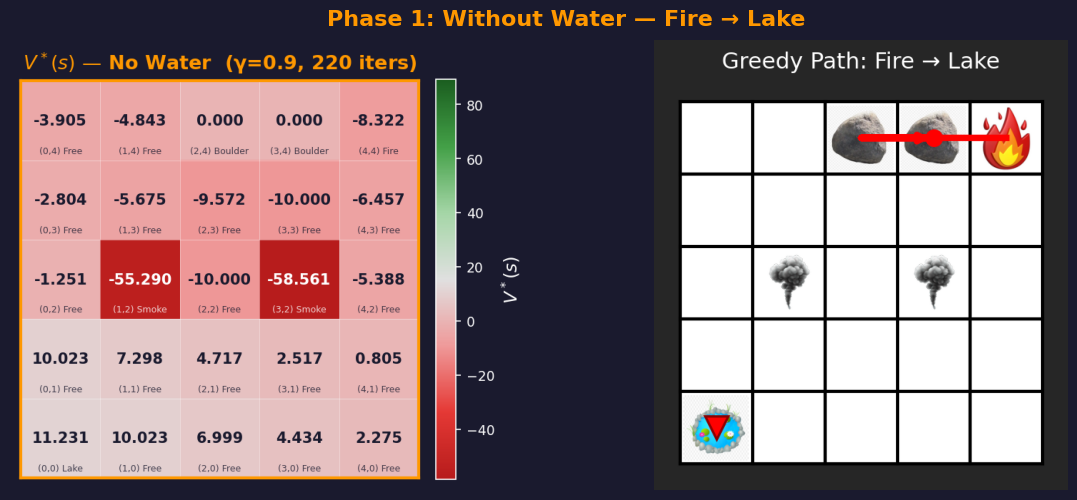

Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.


s_idx =  30  V[s_idx] =  10.765829391281057  nx =  0  ny =  1
s_idx =  26  V[s_idx] =  17.73813795859335  nx =  1  ny =  0
s_idx =  25  V[s_idx] =  13.590184828206223  nx =  0  ny =  0
s_idx =  31  V[s_idx] =  14.068485100894957  nx =  1  ny =  1
s_idx =  27  V[s_idx] =  22.665253122168256  nx =  2  ny =  0
s_idx =  25  V[s_idx] =  13.590184828206223  nx =  0  ny =  0
s_idx =  26  V[s_idx] =  17.73813795859335  nx =  1  ny =  0
s_idx =  32  V[s_idx] =  18.426332029836733  nx =  2  ny =  1
s_idx =  28  V[s_idx] =  28.455774091258196  nx =  3  ny =  0
s_idx =  26  V[s_idx] =  17.73813795859335  nx =  1  ny =  0
s_idx =  27  V[s_idx] =  22.665253122168256  nx =  2  ny =  0
s_idx =  33  V[s_idx] =  24.696544678943088  nx =  3  ny =  1
s_idx =  29  V[s_idx] =  35.096897990042606  nx =  4  ny =  0
s_idx =  27  V[s_idx] =  22.665253122168256  nx =  2  ny =  0
s_idx =  28  V[s_idx] =  28.455774091258196  nx =  3  ny =  0
s_idx =  34  V[s_idx] =  43.20386775178048  nx =  4  ny =  1
s_idx =  28 

Font 'default' does not have a glyph for '\U0001f4a7' [U+1f4a7], substituting with a dummy symbol.


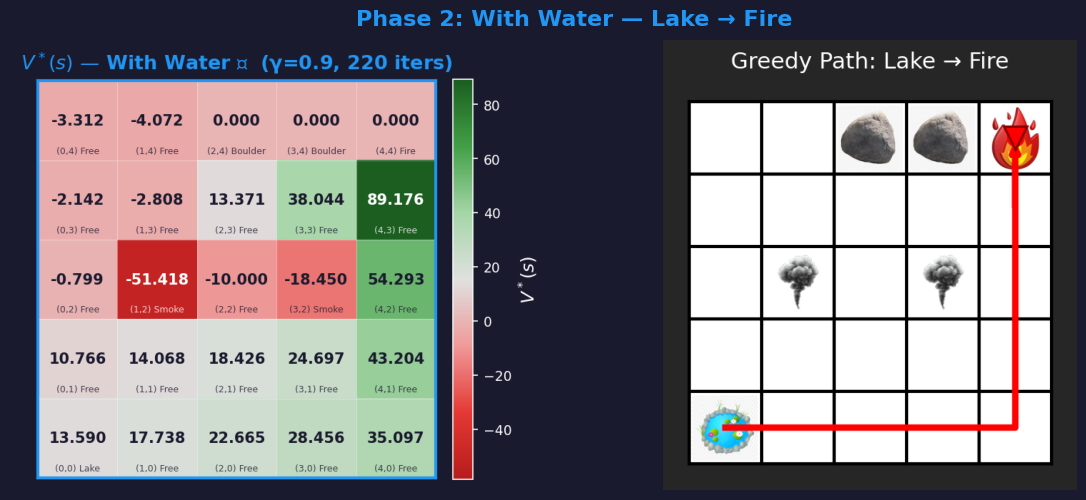

In [67]:
print("===================================================")
print("Q3a:- Optimal Value Function & Greedy Policy Path when gamma is changed to 0.3")
print("===================================================")
import importlib
import core.Plot_generators.Grid_path_generator as gpg
import core.Agent.agent as cAa
import core.Agent.mdp_model as AMM
importlib.reload(AMM)
from core.Agent.mdp_model import FiniteMDP
importlib.reload(gpg)
importlib.reload(cAa)
import core.Agent.mdp_model as rk
importlib.reload(rk)
from core.Agent.agent import Agent
from core.Plot_generators.Grid_path_generator import generate_grid_image
import core.Plot_generators.value_fuction_visuvalizer as Pgv
importlib.reload(Pgv)
from core.Plot_generators.value_fuction_visuvalizer import state_value_fuction_visuvalizer
from core.Plot_generators.figuer_merger import merge_figures
mdp_model_0_point_3 = FiniteMDP()
S, A, P, R, gamma = mdp_model_0_point_3.initialization_MDP_with_DA6400_Question1_manner(0.9)

# Agent + value iteration
agent_gamma_0_point_3 = Agent(mdp_model_0_point_3)
V, n_iters = agent_gamma_0_point_3.value_iteration_on_V(max_iter=1000)
print(f"Value iteration converged in {n_iters} iterations  (γ={gamma})")

# Image1: Without Water (Fire → Lake)
path_no_water = agent_gamma_0_point_3.greedy_path(water=False)
print(f"Path (no water): {path_no_water}  ({len(path_no_water)-1} steps)")

fig_v1, _ = state_value_fuction_visuvalizer(V, S, water=False,
                title=f'$V^*(s)$ — No Water  (γ={gamma}, {n_iters} iters)')
fig_g1, _ = generate_grid_image(S, path=path_no_water, points_of_interest=[(0, 0)],
                title='Greedy Path: Fire → Lake', figsize=(4, 4), show=False, water_phase=0)

merged1, _ = merge_figures(
    figures=[(fig_v1, (0, 0)), (fig_g1, (0, 1))],
    grid=(1, 2),
    grand_title='Phase 1: Without Water — Fire → Lake',
    grand_title_color='#FF9800',
    figsize=(12, 5),
    show=True,
)

# ── Image 2: With Water (Lake → Fire) ──
path_water = agent_gamma_0_point_3.greedy_path(water=True)
print(f"Path (with water): {path_water}  ({len(path_water)-1} steps)")

fig_v2, _ = state_value_fuction_visuvalizer(V, S, water=True,
                title=f'$V^*(s)$ — With Water 💧  (γ={gamma}, {n_iters} iters)')
fig_g2, _ = generate_grid_image(S, path=path_water, points_of_interest=[(4, 4)],
                title='Greedy Path: Lake → Fire', figsize=(4, 4), show=False, water_phase=1)

merged2, _ = merge_figures(
    figures=[(fig_v2, (0, 0)), (fig_g2, (0, 1))],
    grid=(1, 2),
    grand_title='Phase 2: With Water — Lake → Fire',
    grand_title_color='#2196F3',
    figsize=(12, 5),
    show=True,
)

In [4]:
"""fffff"""

'ff'